# 2023 Heatwave_Event
This notebook plots specific RGB recipes (`TrueColor` and `FireTemperature`) from GOES-18 satellite data for July 16, 2023, to July 19, 2023, using the `goes2go` library.

**Author**: Jack Fordyce  
**Date**: October 2025

## Import Required Libraries
The following libraries are used in this notebook:
- `goes2go`: For accessing GOES satellite data.
- `matplotlib`: For plotting the RGB images.
- `cartopy`: For adding map features.
- `pandas`: For handling datetime conversions.
- `imageio`: For creating GIFs.


In [1]:
from goes2go import GOES
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta
import os
import shutil
import pandas as pd
import imageio
import contextlib
import io
from IPython.display import Image


/knight/jan25/envs/jan25_env/lib/python3.12/site-packages/goes2go/data.py:665: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  within=pd.to_timedelta(config["nearesttime"].get("within", "1h")),
/knight/jan25/envs/jan25_env/lib/python3.12/site-packages/goes2go/NEW.py:188: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  within=pd.to_timedelta(config["nearesttime"].get("within", "1h")),


## Clear GOES2GO Cache
This helper function clears the cache directories used by `goes2go`. It ensures that outdated or corrupted data does not interfere with the analysis.

In [2]:
def _clear_goes2go_caches():
    candidates = [
        os.path.join(os.path.expanduser("~"), ".cache", "goes2go"),
        os.path.join(os.path.expanduser("~"), ".goes2go"),
        os.path.join(os.getcwd(), "goes2go-cache"),
        os.path.join(os.getcwd(), "goes2go"),
    ]
    removed = []
    for d in candidates:
        if os.path.exists(d):
            try:
                shutil.rmtree(d)
                removed.append(d)
            except Exception:
                pass
    return removed

## Fetch GOES-18 Data
The function below fetches the GOES-18 satellite data for a specific datetime. It retries fetching the data if an error occurs.

In [3]:
def get_goes18_for_datetime(year, month, day, hour=12, minute=0, within_hours=2, retries=1):
    attempt = 0
    while True:
        try:
            target_time = datetime(year, month, day, hour, minute)
            within = timedelta(hours=within_hours)
            with contextlib.redirect_stdout(io.StringIO()):  
                G18 = GOES(satellite=18).nearesttime(target_time, within=within)
            return G18
        except Exception as e:
            attempt += 1
            if attempt > retries:
                raise
            _clear_goes2go_caches()

## Plot TrueColor RGB Images
This section generates TrueColor RGB images for each time step within the specified time range. The images are saved to the `outputs_TrueColor` directory.

In [4]:
start_time = datetime(2023, 7, 16, 18, 0)
end_time = datetime(2023, 7, 19, 0, 0)
time_step = timedelta(hours=6)

truecolor_output_dir = os.path.join(os.getcwd(), "outputs_TrueColor")
os.makedirs(truecolor_output_dir, exist_ok=True)

In [32]:
current_time = start_time
while current_time <= end_time:
    try:
        with contextlib.redirect_stdout(io.StringIO()): 
            G18 = get_goes18_for_datetime(current_time.year, current_time.month, current_time.day, current_time.hour)

            fig = plt.figure(figsize=(12, 9))
            ax = fig.add_subplot(1, 1, 1, projection=G18.rgb.crs)

            RGB = G18.rgb.TrueColor()
            ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
            ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)
            ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.3)
            # Use the image extent if provided by goes2go so the axes match the satellite coverage.
            img_extent = G18.rgb.imshow_kwargs.get('extent') if isinstance(G18.rgb.imshow_kwargs, dict) else None
            if img_extent is not None:
                try:
                    ax.set_extent(img_extent, crs=ccrs.PlateCarree())
                except Exception:
                    ax.set_extent([-125, -115, 32, 50], crs=ccrs.PlateCarree())



            

            ax.imshow(RGB, **G18.rgb.imshow_kwargs)
            ax.set_title(f"GOES-18 TrueColor", loc="left", fontweight="bold")
            ax.set_title(current_time.strftime("%Y-%m-%d %H:%M UTC"), loc="right")

            plt.subplots_adjust(wspace=0.01)
            outfile = os.path.join(truecolor_output_dir, f"TrueColor_{current_time.strftime('%Y-%m-%d_%H-%M')}.png")
            plt.savefig(outfile, bbox_inches="tight", dpi=150)
            plt.close(fig)
    except Exception:
        pass
    current_time += time_step

## Generate TrueColor GIF
A GIF is created from the TrueColor images, with each frame repeated to ensure slower playback. The GIF is saved in the `outputs_TrueColor` directory.

In [33]:
truecolor_gif_path = os.path.join(truecolor_output_dir, "TrueColor.gif")
frame_repeat = 65  
with imageio.get_writer(truecolor_gif_path, mode="I", duration=12.0, loop=0) as writer:
    for file in sorted(os.listdir(truecolor_output_dir)):
        if file.endswith(".png"):
            frame = imageio.imread(os.path.join(truecolor_output_dir, file))
            for _ in range(frame_repeat):  
                writer.append_data(frame)
print(f" TrueColor GIF created: {truecolor_gif_path}")

/tmp/ipykernel_1959148/600597576.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frame = imageio.imread(os.path.join(truecolor_output_dir, file))


 TrueColor GIF created: /nfs/spare11/atm533/jf774335/scriptstorm/notebooks/outputs_TrueColor/TrueColor.gif


## Display TrueColor GIF
The generated TrueColor GIF is displayed below.

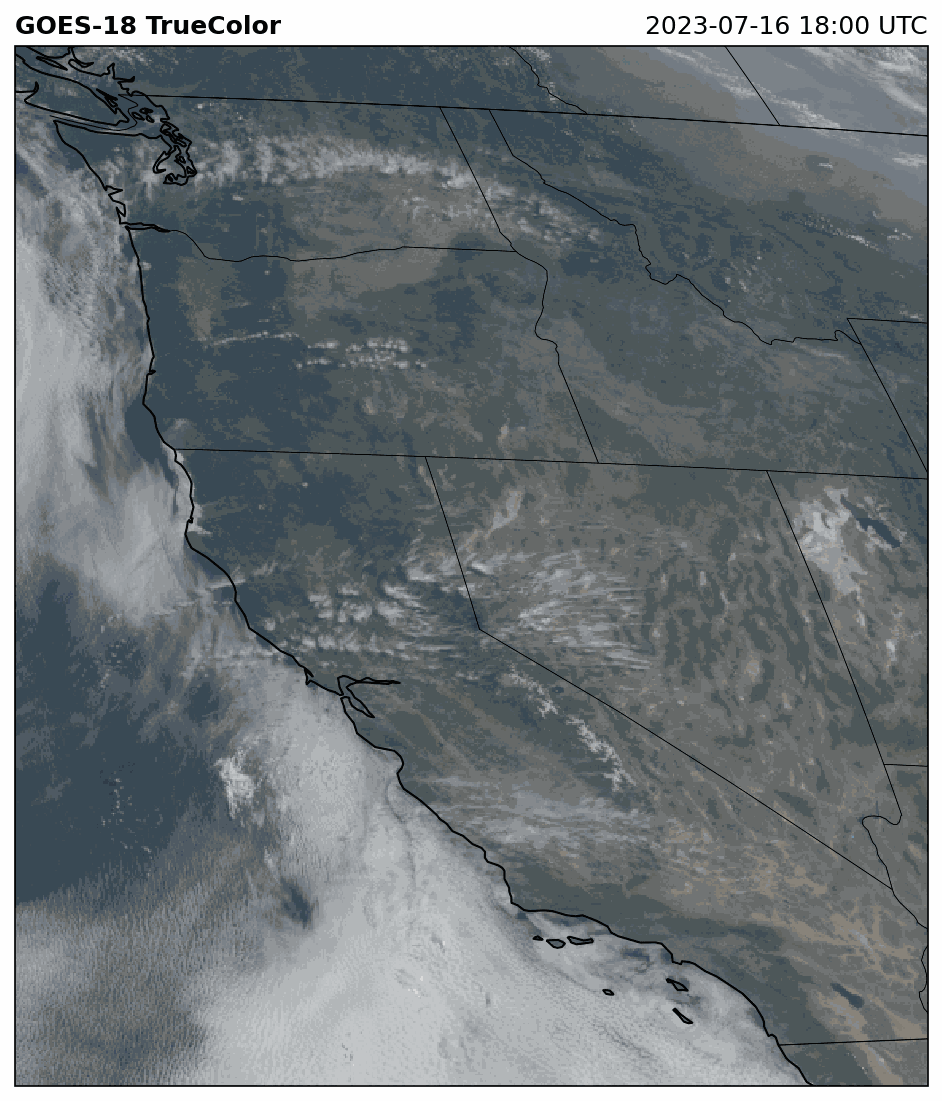

In [34]:
Image(filename=truecolor_gif_path)

## Plot FireTemperature RGB Images
This section generates FireTemperature RGB images for each time step within the specified time range. The images are saved to the `outputs_FireTemperature` directory.

In [35]:
firetemp_output_dir = os.path.join(os.getcwd(), "outputs_FireTemperature")
os.makedirs(firetemp_output_dir, exist_ok=True)

In [36]:
current_time = start_time
while current_time <= end_time:
    try:
        with contextlib.redirect_stdout(io.StringIO()):  
            G18 = get_goes18_for_datetime(current_time.year, current_time.month, current_time.day, current_time.hour)

            fig = plt.figure(figsize=(12, 9))
            ax = fig.add_subplot(1, 1, 1, projection=G18.rgb.crs)

            RGB = G18.rgb.FireTemperature()
            ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
            ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)
            ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.3)
            ax.set_extent([-125, -115, 32, 50], crs=ccrs.PlateCarree())  
            ax.imshow(RGB, **G18.rgb.imshow_kwargs)
            ax.set_title(f"GOES-18 FireTemperature", loc="left", fontweight="bold")
            ax.set_title(current_time.strftime("%Y-%m-%d %H:%M UTC"), loc="right")

            plt.subplots_adjust(wspace=0.01)
            outfile = os.path.join(firetemp_output_dir, f"FireTemperature_{current_time.strftime('%Y-%m-%d_%H-%M')}.png")
            plt.savefig(outfile, bbox_inches="tight", dpi=150)
            plt.close(fig)
    except Exception:
        pass
    current_time += time_step

## Generate FireTemperature GIF
A GIF is created from the FireTemperature images, with each frame repeated to ensure slower playback. The GIF is saved in the `outputs_FireTemperature` directory.

In [37]:
firetemp_gif_path = os.path.join(firetemp_output_dir, "FireTemperature.gif")
frame_repeat = 65  
with imageio.get_writer(firetemp_gif_path, mode="I", duration=12.0, loop=0) as writer:
    for file in sorted(os.listdir(firetemp_output_dir)):
        if file.endswith(".png"):
            frame = imageio.imread(os.path.join(firetemp_output_dir, file))
            for _ in range(frame_repeat):  
                writer.append_data(frame)
print(f" FireTemperature GIF created: {firetemp_gif_path}")

/tmp/ipykernel_1959148/2357075860.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frame = imageio.imread(os.path.join(firetemp_output_dir, file))


 FireTemperature GIF created: /nfs/spare11/atm533/jf774335/scriptstorm/notebooks/outputs_FireTemperature/FireTemperature.gif


## Display FireTemperature GIF
The generated FireTemperature GIF is displayed below.

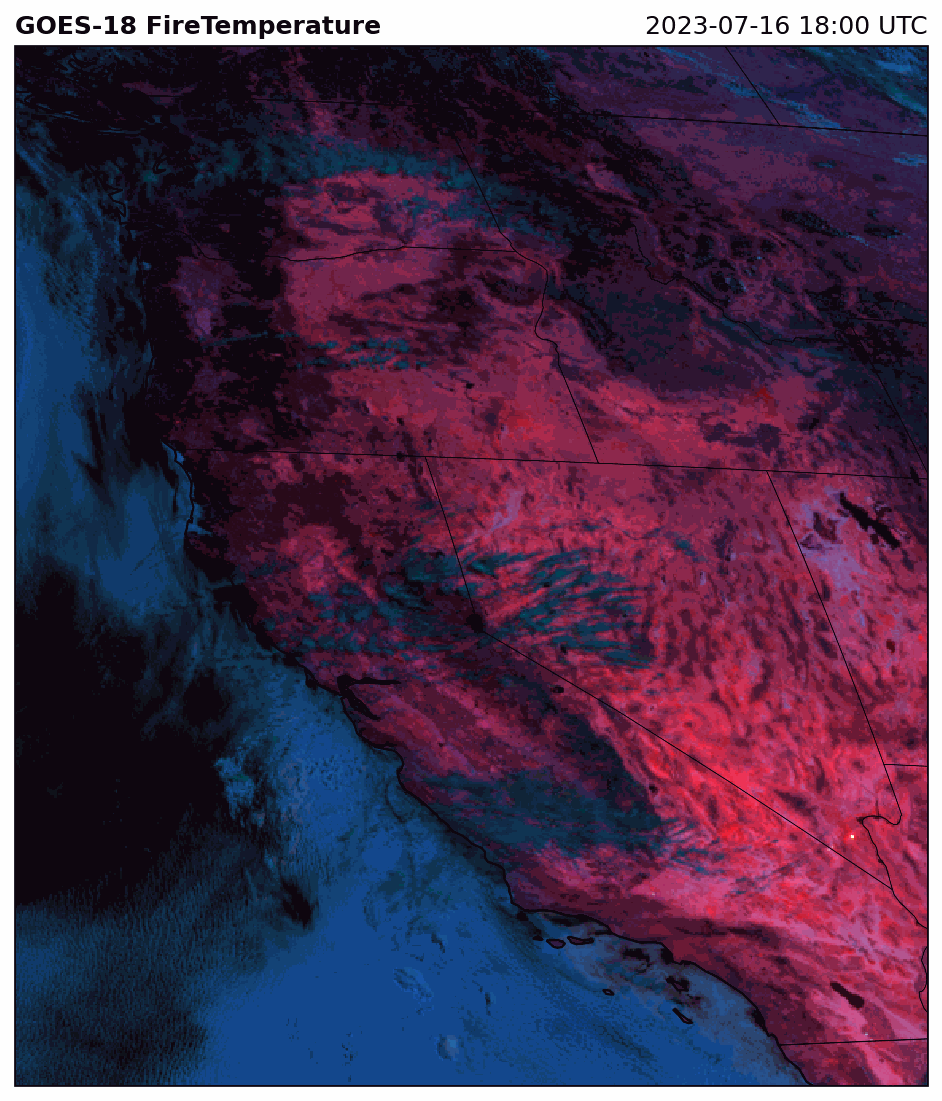

In [38]:
Image(filename=firetemp_gif_path)

## Final Summary

This notebook looked at the 2023 heatwave using GOES-18 satellite data. It made GIFs for both TrueColor and FireTemperature RGB images to show how the heatwave changed over time.

### Key Steps:
- Downloaded GOES-18 data for the chosen time range.
- Processed and plotted TrueColor and FireTemperature RGB images.
- Created and saved GIFs for both image types.

### Outputs:
- TrueColor GIF: outputs_TrueColor/TrueColor.gif
- FireTemperature GIF: outputs_FireTemperature/FireTemperature.gif

### Notes:
- You can change the start_time, end_time, and time_step to look at different periods.
- Make sure all needed libraries are installed before running the notebook.

This notebook gives a simple visual look at how the heatwave developed across the region.


## Data Source 
Blaylock, B. K., 2024: GOES-2-go: Download and display GOES-East and GOES-West data. [Software]. Version 2024.07.0. Available at https://github.com/blaylockbk/goes2go, doi:10.5281/zenodo.4567558


